# 02 - Exploratory Data Analysis

Task 2: understand patterns and factors influencing financial inclusion in Ethiopia,
using the enriched dataset from Task 1.


In [22]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data_loader import load_dataset, validate_schema
from src.eda_utils import get_indicator_series, growth_between_points, pillar_summary, indicator_coverage_table

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Task 2 works with the ENRICHED dataset (Task 1's output), not the raw starter files
df, df_impact, df_ref = load_dataset("../data", use_enriched=True)

# Fail loudly if the enriched dataset hasn't been generated yet, rather than silently
# analyzing the wrong (raw, unenriched) data
result = validate_schema(df, df_ref)
if not result['passed']:
    print("WARNING - schema issues found in the loaded dataset:")
    for issue in result['issues']:
        print(" -", issue)
else:
    print("Schema validation passed.")

obs = df[df['record_type'] == 'observation'].copy()
events = df[df['record_type'] == 'event'].copy()
targets = df[df['record_type'] == 'target'].copy()

print(f"Observations: {len(obs)} | Events: {len(events)} | Targets: {len(targets)} | Impact links: {len(df_impact)}")

Schema validation passed.
Observations: 53 | Events: 12 | Targets: 3 | Impact links: 20


## 1. Dataset Overview

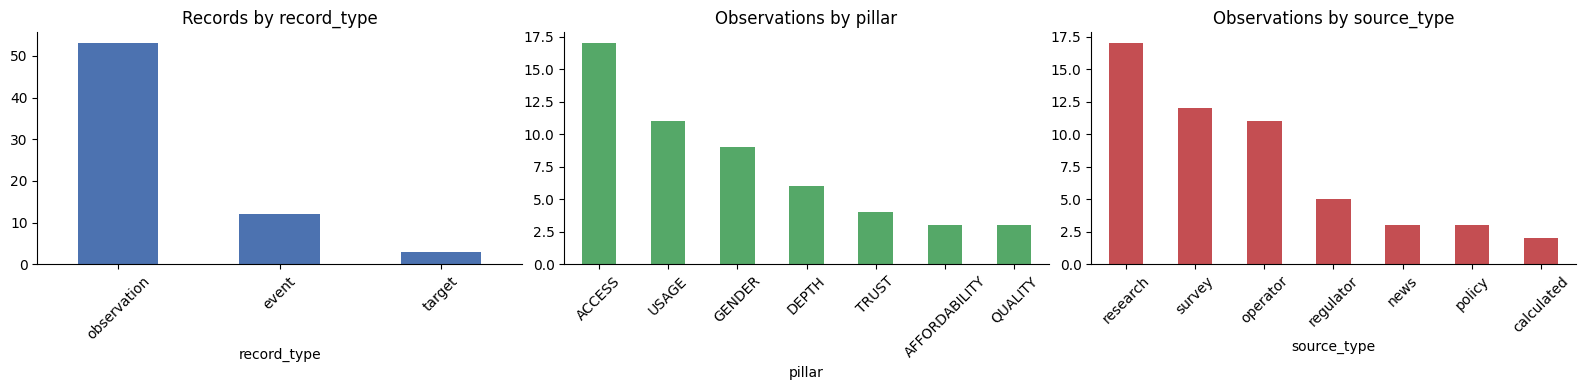

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['record_type'].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Records by record_type')
axes[0].tick_params(axis='x', rotation=45)

obs['pillar'].value_counts().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Observations by pillar')
axes[1].tick_params(axis='x', rotation=45)

obs['source_type'].value_counts().plot(kind='bar', ax=axes[2], color='#C44E52')
axes[2].set_title('Observations by source_type')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Temporal coverage: which years have data for which indicators?

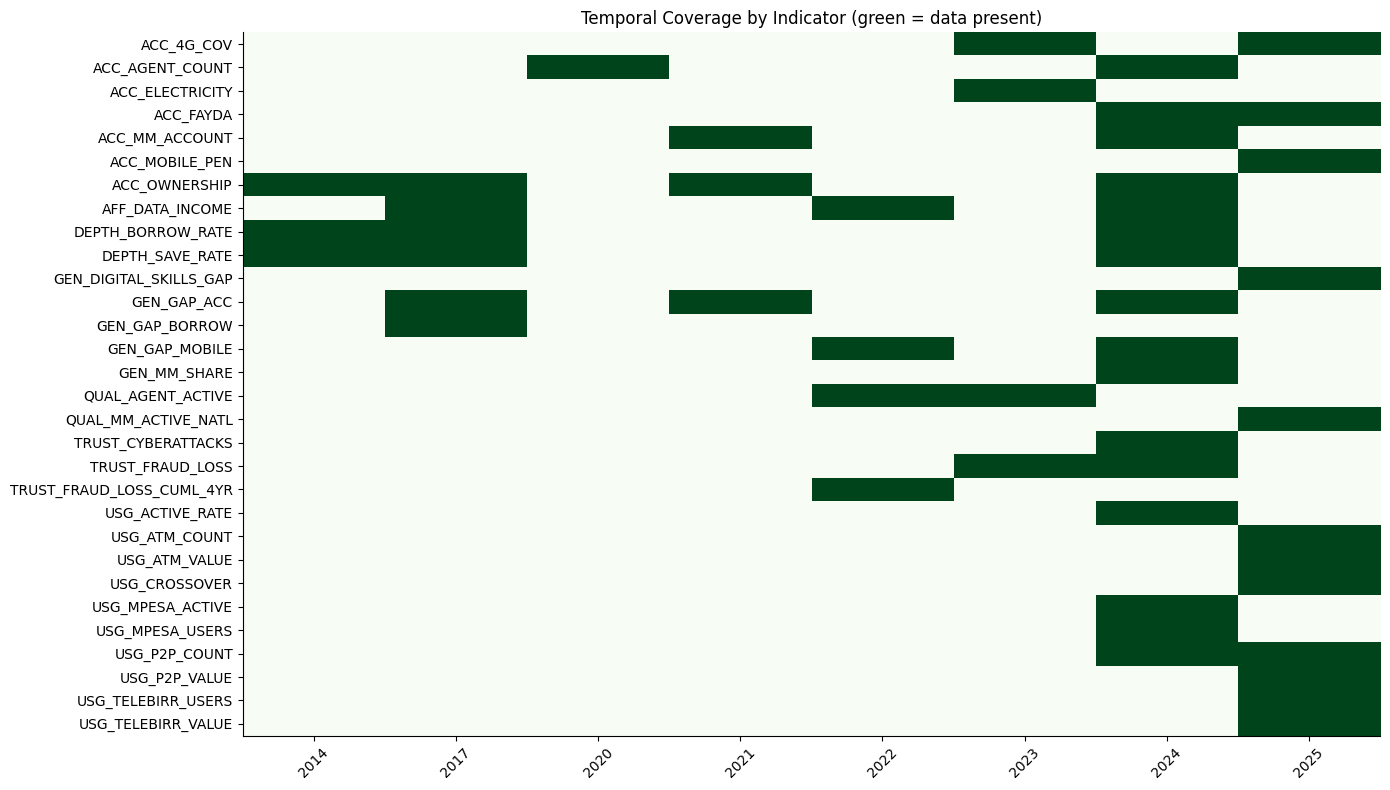

In [24]:
obs['year'] = obs['observation_date'].dt.year
coverage = obs.pivot_table(index='indicator_code', columns='year', values='value_numeric', aggfunc='count')

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(coverage.notna().astype(int), cmap='Greens', aspect='auto')
ax.set_xticks(range(len(coverage.columns)))
ax.set_xticklabels(coverage.columns.astype(int), rotation=45)
ax.set_yticks(range(len(coverage.index)))
ax.set_yticklabels(coverage.index)
ax.set_title('Temporal Coverage by Indicator (green = data present)')
plt.tight_layout()
plt.show()


### Data quality: confidence level distribution

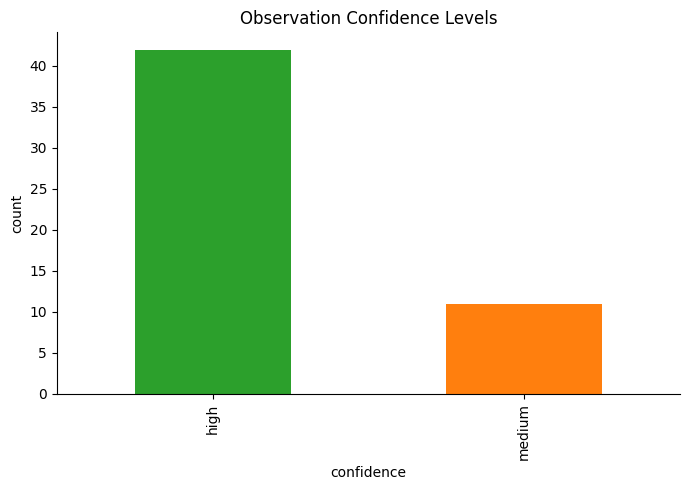

79% of observations are high confidence


In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
conf_order = ['high', 'medium', 'low', 'estimated']
counts = obs['confidence'].value_counts().reindex([c for c in conf_order if c in obs['confidence'].unique()])
counts.plot(kind='bar', ax=ax, color=['#2ca02c', '#ff7f0e', '#d62728', '#7f7f7f'])
ax.set_title('Observation Confidence Levels')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

print(f"{(obs['confidence']=='high').mean():.0%} of observations are high confidence")


### Coverage gaps: indicators with sparse data

In [26]:
indicator_counts = obs['indicator_code'].value_counts().sort_values()
sparse = indicator_counts[indicator_counts <= 1]
print(f"{len(sparse)} of {obs['indicator_code'].nunique()} indicators have only 1 observation (cannot show a trend):")
print(sparse)


16 of 30 indicators have only 1 observation (cannot show a trend):
indicator_code
ACC_MOBILE_PEN               1
USG_ATM_VALUE                1
USG_CROSSOVER                1
USG_TELEBIRR_USERS           1
USG_TELEBIRR_VALUE           1
USG_MPESA_USERS              1
USG_MPESA_ACTIVE             1
USG_ACTIVE_RATE              1
USG_P2P_VALUE                1
GEN_MM_SHARE                 1
ACC_ELECTRICITY              1
TRUST_CYBERATTACKS           1
QUAL_MM_ACTIVE_NATL          1
GEN_GAP_BORROW               1
TRUST_FRAUD_LOSS_CUML_4YR    1
USG_ATM_COUNT                1
Name: count, dtype: int64


## 2. Access Analysis

### Account ownership trajectory (2014-2024)


**Note on data range:** the instructions reference 2011-2024, but Ethiopia was not part of
the first (2011) Global Findex wave, it was added starting with the 2014 round. Verified against
the World Bank's own 2014 Global Findex report (footnote listing Ethiopia among countries newly
added in that wave) and confirmed no source anywhere cites a 2011 Ethiopia account-ownership figure.
2014 (22%) is therefore the true earliest data point, not a gap in this dataset's collection.

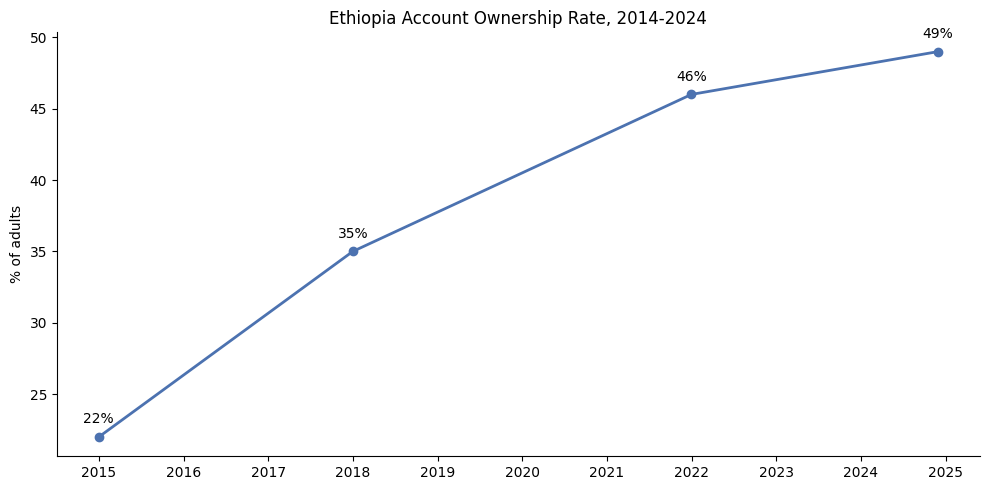

,observation_date,value_numeric
0,2014-12-31,22.0
1,2017-12-31,35.0
2,2021-12-31,46.0
3,2024-11-29,49.0


In [27]:
acc = get_indicator_series(obs, 'ACC_OWNERSHIP')  # reusable helper from src/eda_utils.py

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(acc['observation_date'], acc['value_numeric'], marker='o', linewidth=2, color='#4C72B0')
for _, row in acc.iterrows():
    ax.annotate(f"{row['value_numeric']:.0f}%", (row['observation_date'], row['value_numeric']),
                textcoords="offset points", xytext=(0, 10), ha='center')
ax.set_title("Ethiopia Account Ownership Rate, 2014-2024")
ax.set_ylabel('% of adults')
plt.tight_layout()
plt.show()

acc[['observation_date', 'value_numeric']]


In [28]:
# Reusable function from src/eda_utils.py instead of inline diff() logic
acc = growth_between_points(acc.reset_index(drop=True))

print("Growth between survey years:")
print(acc[['observation_date', 'value_numeric', 'pp_change', 'pp_per_year']].to_string(index=False))

Growth between survey years:
observation_date  value_numeric  pp_change  pp_per_year
      2014-12-31           22.0        NaN          NaN
      2017-12-31           35.0       13.0     4.333333
      2021-12-31           46.0       11.0     2.750000
      2024-11-29           49.0        3.0     1.000000


### Gender gap in account ownership

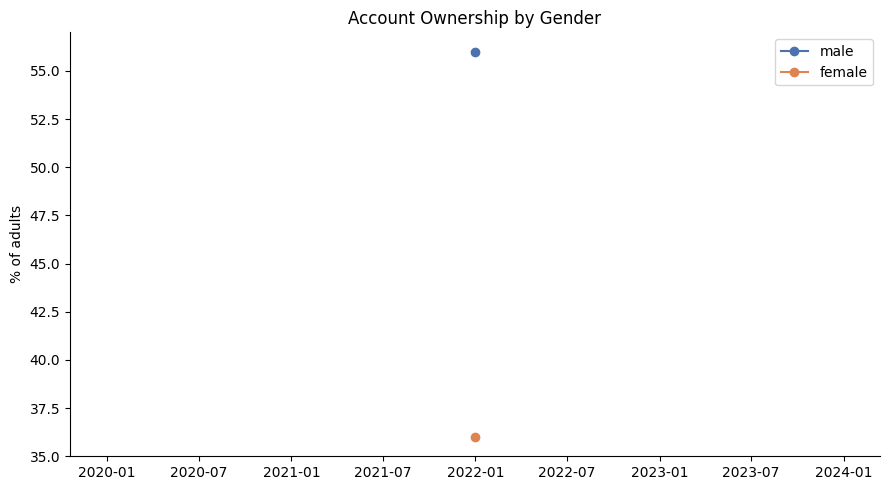


Gender gap (percentage points) over time:
observation_date  value_numeric
      2017-12-31           16.3
      2021-12-31           20.0
      2024-11-29           18.0


In [29]:
gender_acc = obs[(obs['indicator_code'] == 'ACC_OWNERSHIP') & (obs['gender'].isin(['male', 'female']))]
gap = obs[obs['indicator_code'] == 'GEN_GAP_ACC'].sort_values('observation_date')

fig, ax = plt.subplots(figsize=(9, 5))
for g, color in [('male', '#4C72B0'), ('female', '#DD8452')]:
    sub = gender_acc[gender_acc['gender'] == g].sort_values('observation_date')
    ax.plot(sub['observation_date'], sub['value_numeric'], marker='o', label=g, color=color)
ax.set_title('Account Ownership by Gender')
ax.set_ylabel('% of adults')
ax.legend()
plt.tight_layout()
plt.show()

print("\nGender gap (percentage points) over time:")
print(gap[['observation_date', 'value_numeric']].to_string(index=False))


### The 2021-2024 slowdown

Account ownership grew only +3pp (46% → 49%) between 2021 and 2024, despite mobile money accounts
roughly doubling (4.7M → 9.45M) over the same window. Candidate explanations to weigh, cross-referenced
against this dataset's own evidence:


In [30]:
mm = obs[obs['indicator_code'] == 'ACC_MM_ACCOUNT'].sort_values('observation_date')
active = obs[obs['indicator_code'].isin(['USG_ACTIVE_RATE', 'QUAL_MM_ACTIVE_NATL'])].sort_values('observation_date')

print("Mobile money accounts (millions):")
print(mm[['observation_date', 'value_numeric']].to_string(index=False))
print()
print("Active-account rates (different scopes - see notes below):")
print(active[['observation_date', 'indicator', 'value_numeric']].to_string(index=False))
print()
print("Candidate explanations visible in this dataset:")
print("1. Duplicate/overlapping registrations across providers inflate the 9.45M MM-account figure")
print("   relative to unique account holders in the Findex survey (which counts people, not accounts).")
print("2. Low activity: QUAL_MM_ACTIVE_NATL shows only ~15% of ~140M total registered digital accounts")
print("   (across all providers) are active - many 'accounts' may never be used meaningfully.")
print("3. TRUST headwinds: fraud losses rose 30% YoY (REC_0047->REC_0037) and a high-profile bank glitch")
print("   (EVT_0012) occurred in this window - plausible drag on new adoption.")
print("4. Sampling caveat: the 2024 Findex round for Ethiopia excluded Amhara, Tigray, Harari, and Somali")
print("   regions (~30% of population) due to conflict/access constraints - the 49% figure may not be")
print("   directly comparable to earlier full-coverage rounds.")


Mobile money accounts (millions):
observation_date  value_numeric
      2021-12-31           4.70
      2024-11-29           9.45

Active-account rates (different scopes - see notes below):
observation_date                                                  indicator  value_numeric
      2024-12-31                                 Mobile Money Activity Rate           66.0
      2025-12-01 Mobile Money Account Active Rate (National, All Providers)           15.0

Candidate explanations visible in this dataset:
1. Duplicate/overlapping registrations across providers inflate the 9.45M MM-account figure
   relative to unique account holders in the Findex survey (which counts people, not accounts).
2. Low activity: QUAL_MM_ACTIVE_NATL shows only ~15% of ~140M total registered digital accounts
   (across all providers) are active - many 'accounts' may never be used meaningfully.
3. TRUST headwinds: fraud losses rose 30% YoY (REC_0047->REC_0037) and a high-profile bank glitch
   (EVT_0012) occur

## 3. Usage (Digital Payments) Analysis

### Mobile money account penetration trend


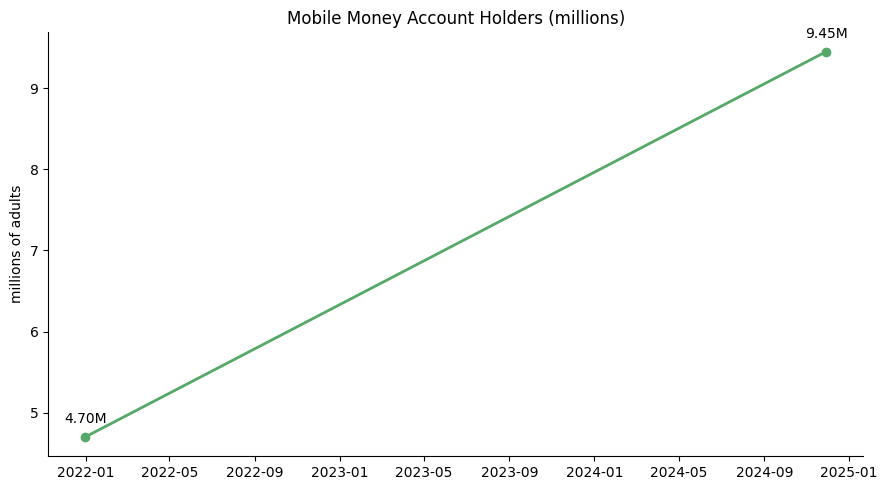

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mm['observation_date'], mm['value_numeric'], marker='o', linewidth=2, color='#55A868')
for _, row in mm.iterrows():
    ax.annotate(f"{row['value_numeric']:.2f}M", (row['observation_date'], row['value_numeric']),
                textcoords="offset points", xytext=(0, 10), ha='center')
ax.set_title('Mobile Money Account Holders (millions)')
ax.set_ylabel('millions of adults')
plt.tight_layout()
plt.show()


### Registered vs. active gap

In [32]:
usage_rows = obs[obs['indicator_code'].isin(['USG_TELEBIRR_USERS', 'USG_MPESA_USERS', 'USG_MPESA_ACTIVE', 'USG_ACTIVE_RATE', 'QUAL_MM_ACTIVE_NATL'])]
usage_rows[['indicator', 'indicator_code', 'value_numeric', 'value_type', 'observation_date']].sort_values('observation_date')


,indicator,indicator_code,value_numeric,value_type,observation_date
22,M-Pesa Registered Users,USG_MPESA_USERS,10800000.0,count,2024-12-31
23,M-Pesa 90-Day Active Users,USG_MPESA_ACTIVE,7100000.0,count,2024-12-31
24,Mobile Money Activity Rate,USG_ACTIVE_RATE,66.0,percentage,2024-12-31
20,Telebirr Registered Users,USG_TELEBIRR_USERS,54840000.0,count,2025-06-30
52,"Mobile Money Account Active Rate (National, Al...",QUAL_MM_ACTIVE_NATL,15.0,percentage,2025-12-01


In [33]:
print("Two different 'active rate' figures exist in this dataset at different scopes:")
print("- USG_ACTIVE_RATE = 66% (2024-12-31): likely a single-platform 90-day active rate")
print("- QUAL_MM_ACTIVE_NATL = 15% (national, ~140M registered accounts across ALL providers, 2025)")
print()
print("The gap between these suggests activity varies hugely by provider/definition - a real registered-vs-")
print("active gap exists, but its exact size depends heavily on which accounts and time window you count.")


Two different 'active rate' figures exist in this dataset at different scopes:
- USG_ACTIVE_RATE = 66% (2024-12-31): likely a single-platform 90-day active rate
- QUAL_MM_ACTIVE_NATL = 15% (national, ~140M registered accounts across ALL providers, 2025)

The gap between these suggests activity varies hugely by provider/definition - a real registered-vs-
active gap exists, but its exact size depends heavily on which accounts and time window you count.


### Payment use cases: P2P vs ATM crossover

In [34]:
p2p = obs[obs['indicator_code'] == 'USG_P2P_COUNT'].sort_values('observation_date')
atm = obs[obs['indicator_code'] == 'USG_ATM_COUNT'].sort_values('observation_date')
crossover_event = events[events['record_id'] == 'EVT_0006']

print("P2P transaction count observations:")
print(p2p[['observation_date', 'value_numeric', 'value_type']].to_string(index=False))
print()
print("ATM transaction count observations:")
print(atm[['observation_date', 'value_numeric', 'value_type']].to_string(index=False))
print()
print("Crossover event (P2P surpasses ATM):")
print(crossover_event[['observation_date', 'indicator']].to_string(index=False))


P2P transaction count observations:
observation_date  value_numeric value_type
      2024-07-07     49700000.0      count
      2025-07-07    128300000.0      count

ATM transaction count observations:
observation_date  value_numeric value_type
      2025-07-07    119300000.0      count

Crossover event (P2P surpasses ATM):
observation_date                           indicator
      2024-10-01 P2P Transaction Count Surpasses ATM


## 4. Infrastructure and Enablers

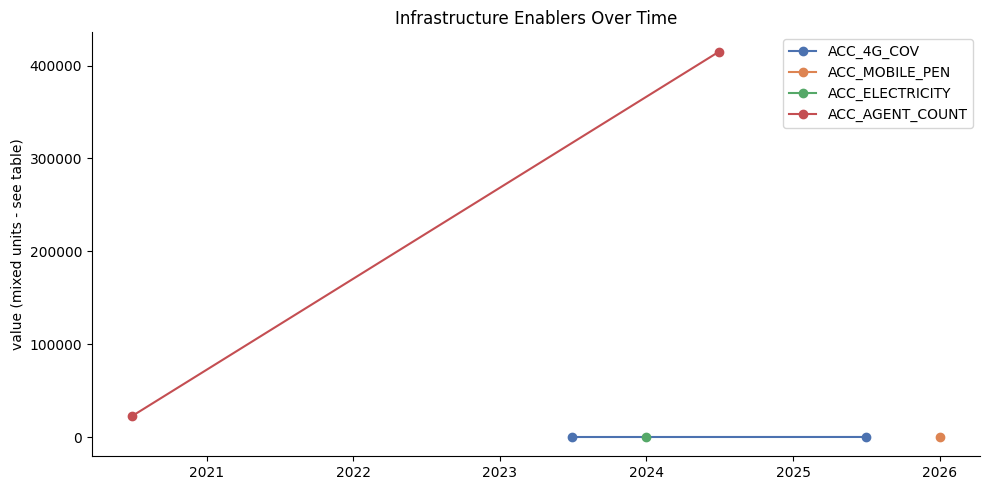

,indicator,indicator_code,value_numeric,value_type,observation_date
8,4G Population Coverage,ACC_4G_COV,37.5,percentage,2023-06-30
9,4G Population Coverage,ACC_4G_COV,70.8,percentage,2025-06-30
46,Mobile Money Agent Count,ACC_AGENT_COUNT,22725.0,count,2020-06-30
47,Mobile Money Agent Count,ACC_AGENT_COUNT,415084.0,count,2024-06-30
48,Electricity Access Rate,ACC_ELECTRICITY,55.4,percentage,2023-12-31
10,Mobile Subscription Penetration,ACC_MOBILE_PEN,61.4,percentage,2025-12-31


In [35]:
infra_codes = ['ACC_4G_COV', 'ACC_MOBILE_PEN', 'ACC_ELECTRICITY', 'ACC_AGENT_COUNT']
infra = obs[obs['indicator_code'].isin(infra_codes)].sort_values(['indicator_code', 'observation_date'])

fig, ax = plt.subplots(figsize=(10, 5))
for code, color in zip(infra_codes, ['#4C72B0', '#DD8452', '#55A868', '#C44E52']):
    sub = infra[infra['indicator_code'] == code]
    if len(sub) > 0:
        ax.plot(sub['observation_date'], sub['value_numeric'], marker='o', label=code, color=color)
ax.set_title('Infrastructure Enablers Over Time')
ax.legend()
ax.set_ylabel('value (mixed units - see table)')
plt.tight_layout()
plt.show()

infra[['indicator', 'indicator_code', 'value_numeric', 'value_type', 'observation_date']]


**Potential leading indicators for Findex outcomes:** agent count and activity rate move well ahead of
Findex survey rounds (which only happen every 2-3 years) and could serve as higher-frequency proxies
for ACCESS/USAGE momentum between official survey rounds.


## 5. Event Timeline and Visual Analysis

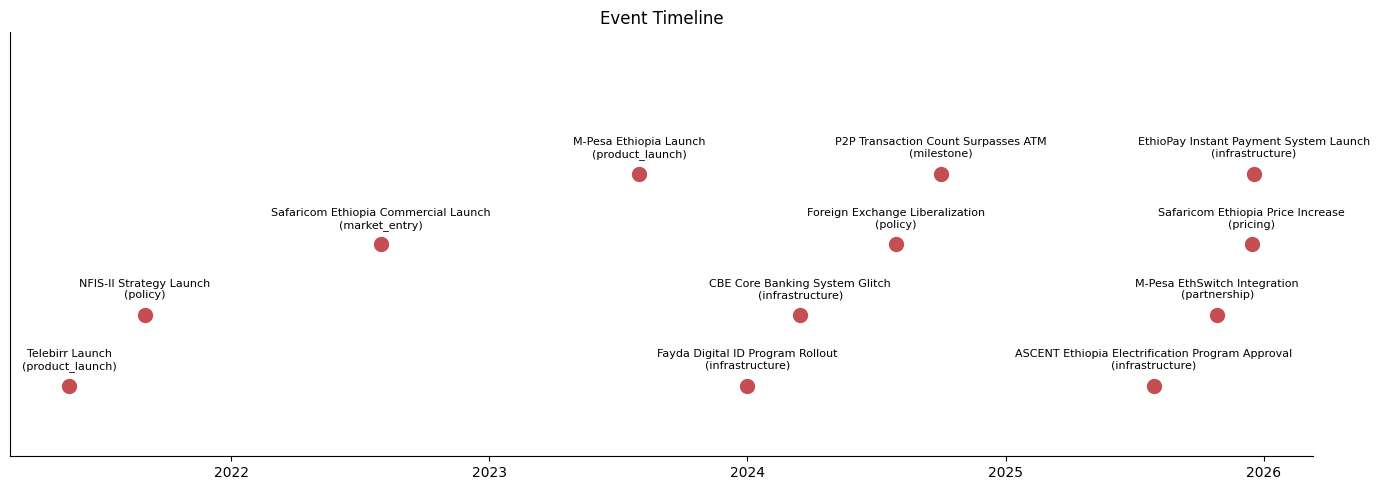

In [36]:
events_sorted = events.sort_values('observation_date')

fig, ax = plt.subplots(figsize=(14, 5))
y_positions = np.arange(len(events_sorted)) % 4
ax.scatter(events_sorted['observation_date'], y_positions, s=100, color='#C44E52', zorder=3)
for (_, row), y in zip(events_sorted.iterrows(), y_positions):
    ax.annotate(f"{row['indicator']}\n({row['category']})", (row['observation_date'], y),
                textcoords="offset points", xytext=(0, 12), ha='center', fontsize=8, rotation=0)
ax.set_yticks([])
ax.set_title('Event Timeline')
ax.set_ylim(-1, 5)
plt.tight_layout()
plt.show()


### Overlay: account ownership + mobile money + key events

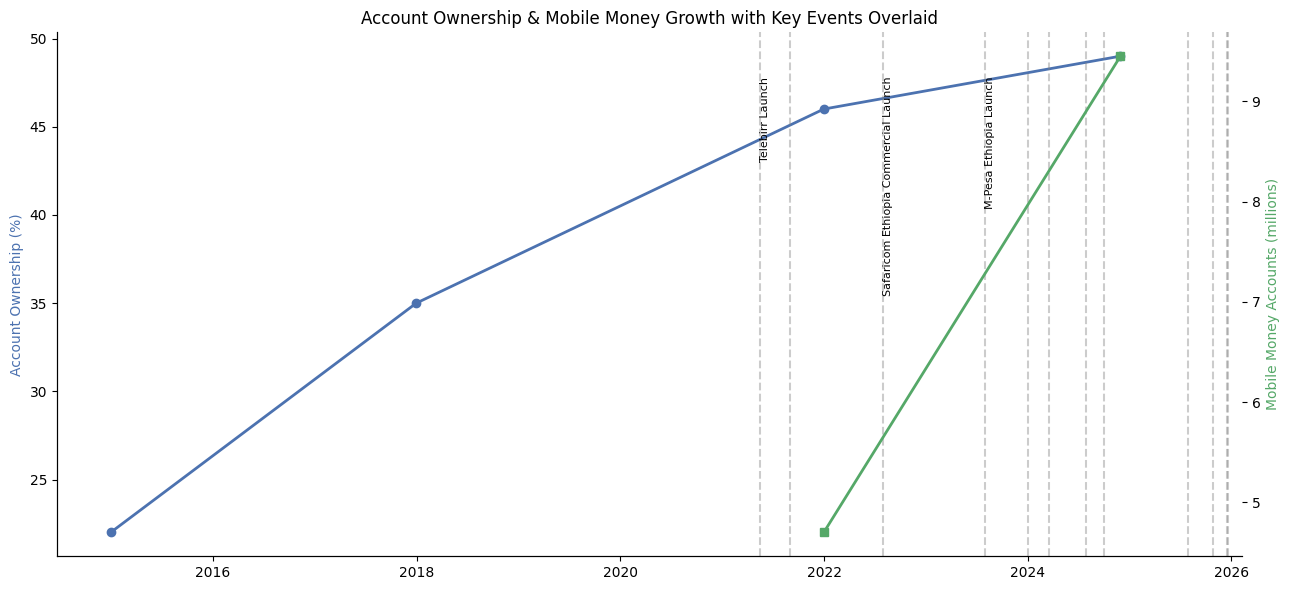

In [37]:
fig, ax1 = plt.subplots(figsize=(13, 6))

ax1.plot(acc['observation_date'], acc['value_numeric'], marker='o', color='#4C72B0', label='Account Ownership (%)', linewidth=2)
ax1.set_ylabel('Account Ownership (%)', color='#4C72B0')

ax2 = ax1.twinx()
ax2.plot(mm['observation_date'], mm['value_numeric'], marker='s', color='#55A868', label='Mobile Money Accounts (M)', linewidth=2)
ax2.set_ylabel('Mobile Money Accounts (millions)', color='#55A868')

for _, row in events_sorted.iterrows():
    ax1.axvline(row['observation_date'], color='gray', linestyle='--', alpha=0.4)

key_events = events_sorted[events_sorted['record_id'].isin(['EVT_0001', 'EVT_0002', 'EVT_0003'])]
for _, row in key_events.iterrows():
    ax1.annotate(row['indicator'], (row['observation_date'], ax1.get_ylim()[1]*0.95),
                 rotation=90, fontsize=8, va='top')

ax1.set_title('Account Ownership & Mobile Money Growth with Key Events Overlaid')
plt.tight_layout()
plt.show()


**Visual read:**
- **Telebirr (May 2021)** launches right before the 2021 Findex round (Dec 2021) too close in time
  for the survey to capture its effect; its impact shows up in the *2021→2024* mobile-money-account
  growth instead (impact_links IMP_0001-0003 estimate a 6-12mo lag).
- **Safaricom market entry (Aug 2022)** sits in the gap between Findex rounds no direct before/after
  ACC_OWNERSHIP comparison is possible with only 2 survey points bracketing it.
- **M-Pesa launch (Aug 2023)** mobile money accounts nearly doubled by the 2024 survey, consistent
  with a real effect, but Telebirr's simultaneous growth (50M+ users by 2026 per REC_0038's source
  context) makes it hard to isolate M-Pesa's individual contribution from this data alone.


## 6. Correlation Analysis

Indicators with enough time coverage (>=3 points) for correlation: ['ACC_OWNERSHIP', 'AFF_DATA_INCOME', 'DEPTH_BORROW_RATE', 'DEPTH_SAVE_RATE', 'GEN_GAP_ACC']


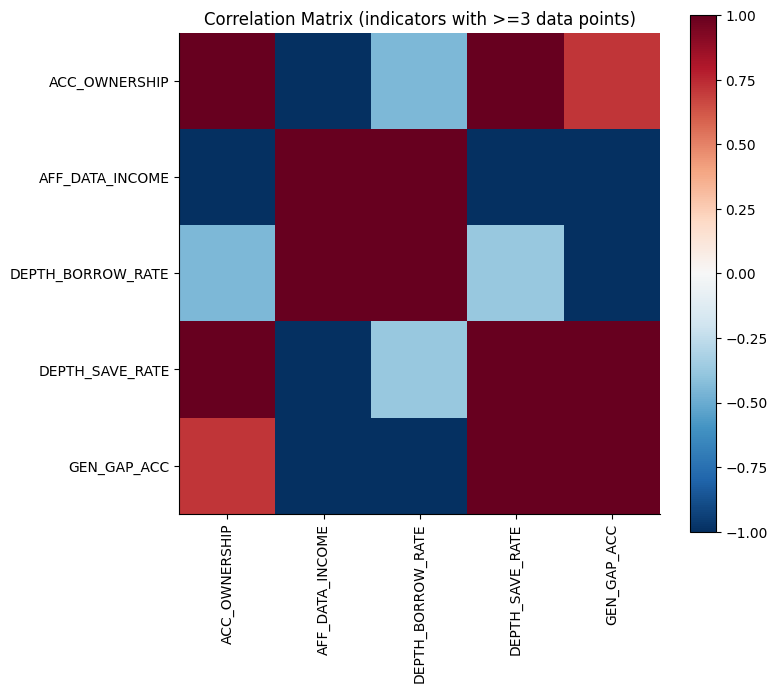

In [38]:
pivot = obs.pivot_table(index='year', columns='indicator_code', values='value_numeric', aggfunc='mean')
pivot_dense = pivot.dropna(axis=1, thresh=3)  # keep only indicators with >=3 years of data

print(f"Indicators with enough time coverage (>=3 points) for correlation: {list(pivot_dense.columns)}")
corr = pivot_dense.corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
plt.colorbar(im)
ax.set_title('Correlation Matrix (indicators with >=3 data points)')
plt.tight_layout()
plt.show()


**Caveat on correlation with this dataset:** most indicators have only 2-4 points total across very
different years, so these correlations reflect broad co-movement over a decade of general digitization,
not a rigorous statistical relationship. Treat as directional hints, not evidence.


In [39]:
# What impact_links already claim, by pillar
impact_summary = df_impact.groupby(['pillar', 'impact_direction']).size().unstack(fill_value=0)
print("Existing impact_link claims by affected pillar and direction:")
impact_summary


Existing impact_link claims by affected pillar and direction:


impact_direction,decrease,increase,stabilize
pillar,,,
ACCESS,0,6,0
AFFORDABILITY,1,2,0
GENDER,1,0,0
TRUST,1,0,0
USAGE,0,8,1


In [40]:
access_drivers = df_impact[df_impact['pillar'] == 'ACCESS'].merge(
    events[['record_id', 'indicator']], left_on='parent_id', right_on='record_id', suffixes=('', '_event')
)
usage_drivers = df_impact[df_impact['pillar'] == 'USAGE'].merge(
    events[['record_id', 'indicator']], left_on='parent_id', right_on='record_id', suffixes=('', '_event')
)

print("Events linked to ACCESS:")
print(access_drivers[['indicator', 'related_indicator', 'impact_direction', 'impact_magnitude', 'confidence']].to_string(index=False))
print()
print("Events linked to USAGE:")
print(usage_drivers[['indicator', 'related_indicator', 'impact_direction', 'impact_magnitude', 'confidence']].to_string(index=False))


Events linked to ACCESS:
                                                                           indicator related_indicator impact_direction impact_magnitude confidence
                                                Telebirr effect on Account Ownership     ACC_OWNERSHIP         increase             high     medium
                                                     Safaricom effect on 4G Coverage        ACC_4G_COV         increase           medium     medium
                                          M-Pesa effect on Mobile Money Account Rate    ACC_MM_ACCOUNT         increase           medium     medium
                                                   Fayda effect on Account Ownership     ACC_OWNERSHIP         increase           medium     medium
ASCENT Ethiopia Electrification Program Approval effect on Mobile Money Account Rate    ACC_MM_ACCOUNT         increase              low  estimated
                                 NFIS-II Strategy Launch effect on Account Ownership   

## 7. Key Insights

**1. Account ownership growth has decelerated sharply despite explosive mobile money growth.**
+13pp (2014→2017), +11pp (2017→2021), but only +3pp (2021→2024) even as mobile money accounts
roughly doubled (4.7M→9.45M) in that same final window. Ownership and mobile-money-account counts
have decoupled.

**2. The "registered vs. active" gap is large and possibly the core explanation for #1.**
NBE's own national figures show only ~15% of ~140M registered digital accounts are active
(QUAL_MM_ACTIVE_NATL), while agent activity sits at just 42% even after doubling from a 17% baseline.
Ethiopia may be registering accounts far faster than it's converting them into real usage or
first-time formal account ownership.

**3. The gender gap in account ownership has narrowed but remains substantial.**
20pp gap in 2021 → 18pp gap in 2024 (male 57% vs. female ~39-42%, depending on source). A newly
added digital-skills gap (66% of women vs. 60% of men lack mobile-money skills) suggests the
remaining barrier may be shifting from access to literacy/confidence.

**4. Rising fraud and a high-profile trust incident coincide with the ownership slowdown.**
Banking-sector fraud losses rose 30% YoY (1.0bn→1.3bn ETB, FY22/23→FY23/24) alongside a major CBE
system glitch (Mar 2024) that received wide domestic and international coverage plausible, though
unproven, drags on new-account trust during exactly the window ownership growth stalled.

**5. Infrastructure enablers (electricity, agent networks) still lag urban/national averages.**
Electricity access sits at 55.4% nationally — meaning nearly half the population faces a basic
constraint on device charging and agent-point uptime that isn't captured by ACCESS-pillar metrics alone.

**Data gaps most limiting this analysis:**
- Almost every non-ACCESS/USAGE indicator has only 1-3 data points — too sparse for real trend or
  correlation analysis, only enough to establish direction
- No urban/rural disaggregation exists for account ownership in this dataset, despite the Additional
  Data Points Guide flagging this as a known ~75%-rural-exclusion issue
- The 2024 Findex round excluded ~30% of Ethiopia's population (Amhara, Tigray, Harari, Somali) —
  a major, easy-to-miss comparability caveat for any 2021→2024 trend claim

**Hypotheses for the impact modeling phase (Task 3):**
- H1: The registered-active gap, not new registrations, is the binding constraint on ACCESS growth
  going forward, worth modeling USAGE(active) as a gate on ACCESS(ownership) rather than a parallel outcome
- H2: TRUST shocks (fraud, system incidents) have a short, sharp negative effect on new registrations
  with a 1-3 month lag, based on IMP_0020's timing assumption
- H3: Electricity/agent-network expansion is a leading indicator for ACCESS with a long lag (12-24mo),
  not a same-period driver
